In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, Dataset, random_split
import random

from IPython.display import display

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
torch.set_default_device(DEVICE)

NameError: name 'torch' is not defined

In [3]:
data = pd.read_csv('ranking_dataset.csv')
data.describe()
X = data.iloc[:, 0:10]
y = data.iloc[:, 10:20]
display(X.describe())
display(y.describe())
display(X.head())
display(y.head())

,val_0,val_1,val_2,val_3,val_4,val_5,val_6,val_7,val_8,val_9
count,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,500.537200,506.623500,501.396300,501.42390,493.817300,495.837500,501.616300,505.314100,500.361700,500.02570
std,290.444477,289.410167,288.372805,289.29438,289.255414,290.777883,288.663129,288.731189,288.747163,290.38134
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,248.000000,255.750000,256.000000,251.00000,244.000000,240.000000,250.750000,257.000000,249.000000,248.00000
50%,500.000000,511.000000,500.000000,505.00000,489.000000,496.000000,504.000000,504.000000,501.500000,501.00000
75%,755.000000,757.000000,752.250000,754.25000,745.000000,746.000000,753.250000,757.000000,752.000000,754.00000
max,999.000000,999.000000,999.000000,999.00000,999.000000,999.000000,999.000000,999.000000,999.000000,999.00000


,rank_0,rank_1,rank_2,rank_3,rank_4,rank_5,rank_6,rank_7,rank_8,rank_9
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.508600,4.546900,4.49630,4.511000,4.444500,4.443100,4.506400,4.544000,4.498000,4.501200
std,2.876031,2.888639,2.86056,2.866409,2.884086,2.878297,2.857022,2.867523,2.861261,2.882365
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,5.000000,5.000000,4.00000,5.000000,4.000000,4.000000,5.000000,5.000000,4.000000,4.000000
75%,7.000000,7.000000,7.00000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
max,9.000000,9.000000,9.00000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000


,val_0,val_1,val_2,val_3,val_4,val_5,val_6,val_7,val_8,val_9
0,542,67,876,414,26,335,620,924,950,113
1,378,14,210,954,231,572,315,295,567,706
2,749,876,73,111,899,213,541,769,287,219
3,372,880,475,329,733,564,739,376,632,10
4,186,822,577,519,707,123,143,294,693,677


,rank_0,rank_1,rank_2,rank_3,rank_4,rank_5,rank_6,rank_7,rank_8,rank_9
0,5,1,7,4,0,3,6,8,9,2
1,5,0,1,9,2,7,4,3,6,8
2,6,8,0,1,9,2,5,7,4,3
3,2,9,4,1,7,5,8,3,6,0
4,2,9,5,4,8,0,1,3,7,6


In [4]:
class RankingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = RankingDataset(X, y)
train_dataloader, test_dataloader, valid_dataloader = [DataLoader(x, batch_size=32, shuffle=True) for x in random_split(dataset, [0.6, 0.2, 0.2])]

In [5]:
# Since we're ranking only 10 numbers, we can use a simple MLP to learn the ranking function.

class MLP(torch.nn.Module):
    def __init__(self):
        """Initialize a module with the following architecture:
        - Linear (10)
        - ReLU
        - Linear (64)
        - ReLU
        - Linear (64)
        - ReLU
        - Linear (64)
        - ReLU
        - Linear (10)
        """
        super(MLP, self).__init__()
        self.layers = torch.nn.Sequential(
            torch.nn.Linear(10, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.layers(x)

model = MLP().to(DEVICE)

In [6]:
def train(model, train_dataloader, valid_dataloader, epochs=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = torch.nn.MSELoss()

    losses = []
    valid_losses = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_dataloader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        losses.append(total_loss / len(train_dataloader))
        print(f"Epoch {epoch+1}/{epochs}, Loss: {losses[-1]:.4f}")

        model.eval()
        with torch.no_grad():
            valid_loss = 0
            for X_batch, y_batch in valid_dataloader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                valid_loss += loss.item()
        valid_losses.append(valid_loss / len(valid_dataloader))
        print(f"Validation Loss: {valid_losses[-1]:.4f}")

    return losses, valid_losses

Epoch 1/100, Loss: 16.2725
Validation Loss: 3.0549
Epoch 2/100, Loss: 2.3596
Validation Loss: 1.8734
Epoch 3/100, Loss: 1.7152
Validation Loss: 1.5770
Epoch 4/100, Loss: 1.4822
Validation Loss: 1.4384
Epoch 5/100, Loss: 1.3720
Validation Loss: 1.4150
Epoch 6/100, Loss: 1.2659
Validation Loss: 1.2775
Epoch 7/100, Loss: 1.2290
Validation Loss: 1.2750
Epoch 8/100, Loss: 1.1949
Validation Loss: 1.2168
Epoch 9/100, Loss: 1.1607
Validation Loss: 1.1868
Epoch 10/100, Loss: 1.1439
Validation Loss: 1.1728
Epoch 11/100, Loss: 1.1261
Validation Loss: 1.1138
Epoch 12/100, Loss: 1.0928
Validation Loss: 1.1210
Epoch 13/100, Loss: 1.0733
Validation Loss: 1.0842
Epoch 14/100, Loss: 1.0595
Validation Loss: 1.1588
Epoch 15/100, Loss: 1.0432
Validation Loss: 1.0734
Epoch 16/100, Loss: 1.0224
Validation Loss: 1.0746
Epoch 17/100, Loss: 1.0122
Validation Loss: 1.0251
Epoch 18/100, Loss: 1.0036
Validation Loss: 1.0555
Epoch 19/100, Loss: 0.9899
Validation Loss: 1.0419
Epoch 20/100, Loss: 0.9768
Validation L

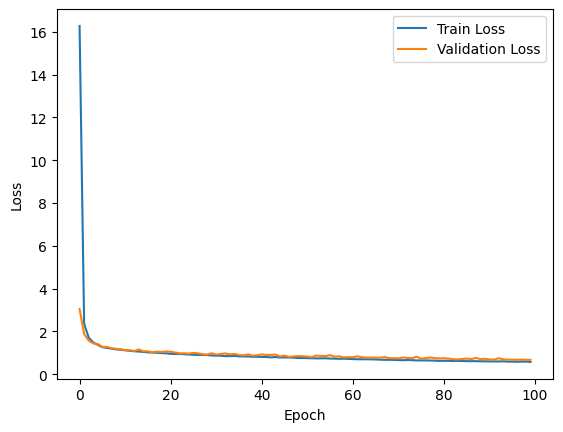

In [7]:
train_losses, valid_losses = train(model, train_dataloader, valid_dataloader, epochs=100)
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [9]:
# Test the model on the test set
model.eval()
with torch.no_grad():
    test_loss = 0
    for X_batch, y_batch in test_dataloader:
        outputs = model(X_batch.to(DEVICE))
        loss = torch.nn.MSELoss()(outputs, y_batch.to(DEVICE))
        test_loss += loss.item()
print(f"Test Loss: {test_loss / len(test_dataloader):.4f}")

Test Loss: 0.6771


In [81]:
accuracies = []
for X_batch, y_batch in test_dataloader:
    # Inputs:
    # print(X_batch[0])
    # Inputs sorted by the true ranking:
    predictions = torch.argsort(torch.argsort(model(X_batch.to(DEVICE)).cpu(), dim=1), dim=1)
    # Predictions sorted by the predicted ranking:
    # print(torch.gather(X_batch, dim=1, index=torch.argsort(y_batch, dim=1))[0])
    # print(torch.gather(X_batch, dim=1, index=torch.argsort(predictions, dim=1))[0])
    # Calculate accuracy:
    accuracies.extend((predictions == y_batch).float().mean(dim=1).tolist())

Average accuracy on test set: 0.6956


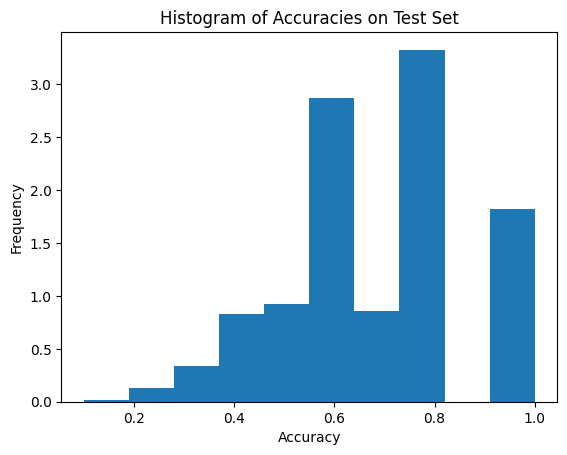

In [83]:
# Plot histogram of accuracies:
print(f"Average accuracy on test set: {sum(accuracies) / len(accuracies):.4f}")
plt.hist(accuracies, bins=10, density=True)
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.title('Histogram of Accuracies on Test Set')
plt.show()

In [85]:
print(f"Percent of arrays it correctly ranked: {sum([1 for acc in accuracies if acc == 1]) / len(accuracies) * 100:.2f}%")

Percent of arrays it correctly ranked: 16.40%


In [56]:
# Here is an example of how the model predicts the ranking of a sample input:
i = random.randint(0, len(test_dataloader.dataset) - 1)
sample_input = (
    torch.tensor(X.iloc[i].values, dtype=torch.float32).unsqueeze(0).to(DEVICE)
)

predicted_ranking = model(sample_input).squeeze().detach().cpu().numpy()
x = X.iloc[i].to_numpy()
y_true = y.iloc[i].to_numpy()

print(f"Input:                             {x}")
print(f"Predicted Ranking:                 {predicted_ranking}")
print(f"True Ranking:                      {y_true}")
print(f"Predicted (argsorted):             {np.argsort(np.argsort(predicted_ranking))}")
print(f"True order:                        {x[np.argsort(y_true)]}")
print(f"Input sorted by predicted ranking: {x[np.argsort(predicted_ranking)]}")

Input:                             [109 112 449 545 341 298 445  51 656 354]
Predicted Ranking:                 [2.4153588 2.087431  5.5452237 6.436309  4.5395894 3.7404513 5.148776
 1.1591232 7.479513  4.5443974]
True Ranking:                      [1 2 7 8 4 3 6 0 9 5]
Predicted (argsorted):             [2 1 7 8 4 3 6 0 9 5]
True order:                        [ 51 109 112 298 341 354 445 449 545 656]
Input sorted by predicted ranking: [ 51 112 109 298 341 354 445 449 545 656]
